# Model Training Tests

In [1]:
# Libraries and functions
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from models import *


# Function to flatten images based on their dimensionality
def preprocessing_input(x, labels, device='cpu', model='MLP'):
    if model.__class__.__name__ in ['CNN', 'ResNet9', 'LeNet5Flexible']:
        return x.to(device), labels.to(device)
    elif model.__class__.__name__ in ['MLP', 'LinearModel']:
        if x.dim() == 4:  # Images have shape (batch_size, channels, height, width)
            return x.view(x.size(0), -1).to(device), labels.to(device)
        elif x.dim() == 2:
            return x.to(device), labels.to(device)
        else:
            raise ValueError("Input have an unexpected shape. Expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")

def evaluate_test(model, test_loader, device='cpu'):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = preprocessing_input(images, labels, device, model)
            outputs = model(images)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
                predictions.append(outputs.cpu().numpy().flatten())
                actuals.append(labels.cpu().numpy().flatten())
            elif model.task_type == 'classification':
                labels = labels.long()
                predictions.append(outputs.cpu().numpy())
                actuals.append(labels.cpu().numpy())

    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)
    
    if model.task_type == 'regression':
        # Calculate regression metrics
        mse = mean_squared_error(actuals, predictions)
        r2 = r2_score(actuals, predictions)
        
        print(f' - Mean Squared Error: {mse:.4f}')
        print(f' - R² Score: {r2:.4f}')
        
        return mse, r2
    
    elif model.task_type == 'classification':
        if predictions.shape[1] == 1:
            # Binary classification: use thresholding
            predicted_classes = (predictions > 0.5).astype(int).flatten()
            actual_classes = actuals.flatten()
        else:
            # Multi-class classification: apply argmax to get predicted classes
            predicted_classes = np.argmax(predictions, axis=1)
            actual_classes = actuals
            
        # Calculate classification metrics
        accuracy = accuracy_score(actual_classes, predicted_classes)
        precision = precision_score(actual_classes, predicted_classes, average='weighted')
        recall = recall_score(actual_classes, predicted_classes, average='weighted')
        f1 = f1_score(actual_classes, predicted_classes, average='weighted')
        
        print(f' - Accuracy: {accuracy:.4f}')
        print(f' - Precision: {precision:.4f}')
        print(f' - Recall: {recall:.4f}')
        print(f' - F1 Score: {f1:.4f}')
        
        return accuracy, precision, recall, f1

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu'):
    best_model = None
    best_val_loss = float('inf')
    final_model = None
    metrics = {'loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = preprocessing_input(images, labels, device, model)  # Flatten the image according to its dimensionality
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)  # Convert labels to float for regression
            elif model.task_type == 'classification':
                labels = labels.long()  # Ensure labels are in long format for classification
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        # Calculate average training loss
        epoch_loss = running_loss / len(train_loader.dataset)
        metrics['loss'].append(epoch_loss)
        
        # Evaluate on the validation set
        val_loss = evaluate(model, val_loader, criterion, device=device)
        metrics['val_loss'].append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()  # Save the best model
            
        # Save the final model at the end of training
        final_model = model.state_dict()
    
    # Load the best model for return
    model.load_state_dict(best_model)
    best_model_instance = model
    
    return best_model_instance, final_model, metrics

def evaluate(model, val_loader, criterion, device='cpu'):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = preprocessing_input(images, labels, device, model)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
            elif model.task_type == 'classification':
                labels = labels.long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    
    return val_loss / len(val_loader.dataset)

def plot_training_metrics(metrics, dataset):
    # Extract losses
    epochs = list(range(1, len(metrics['loss']) + 1))
    train_losses = metrics['loss']
    val_losses = metrics['val_loss']
    
    # Find the epoch with the minimum validation loss
    min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
    min_val_loss = min(val_losses)
    
    # Create a plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=epochs, y=train_losses, label='Training Loss')
    sns.lineplot(x=epochs, y=val_losses, label='Validation Loss')
    
    # Mark the minimum validation loss with a star
    plt.scatter(min_val_loss_epoch, min_val_loss, color='red', marker='*', s=200, label='Min Validation Loss')
    
    # Add titles and labels
    plt.title(f'Training and Validation Loss - {dataset.upper()}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    if not os.path.exists('./images'):
        os.makedirs('./images')
    plt.savefig(f'./images/{dataset}_training_loss.png')
    plt.show()

## 1) Linear Regressor

MPS is available


Training on MNIST dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18278/3749027226.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datas

Epoch [1/40], Loss: 1.6303, Val Loss: 1.5687
Epoch [2/40], Loss: 1.5599, Val Loss: 1.5563
Epoch [3/40], Loss: 1.5505, Val Loss: 1.5490
Epoch [4/40], Loss: 1.5452, Val Loss: 1.5472
Epoch [5/40], Loss: 1.5416, Val Loss: 1.5461
Epoch [6/40], Loss: 1.5388, Val Loss: 1.5428
Epoch [7/40], Loss: 1.5365, Val Loss: 1.5413
Epoch [8/40], Loss: 1.5349, Val Loss: 1.5407
Epoch [9/40], Loss: 1.5334, Val Loss: 1.5399
Epoch [10/40], Loss: 1.5319, Val Loss: 1.5391
Epoch [11/40], Loss: 1.5310, Val Loss: 1.5385
Epoch [12/40], Loss: 1.5295, Val Loss: 1.5384
Epoch [13/40], Loss: 1.5289, Val Loss: 1.5390
Epoch [14/40], Loss: 1.5281, Val Loss: 1.5372
Epoch [15/40], Loss: 1.5276, Val Loss: 1.5375
Epoch [16/40], Loss: 1.5266, Val Loss: 1.5377
Epoch [17/40], Loss: 1.5257, Val Loss: 1.5368
Epoch [18/40], Loss: 1.5251, Val Loss: 1.5367
Epoch [19/40], Loss: 1.5248, Val Loss: 1.5365
Epoch [20/40], Loss: 1.5241, Val Loss: 1.5365
Epoch [21/40], Loss: 1.5237, Val Loss: 1.5372
Epoch [22/40], Loss: 1.5234, Val Loss: 1.53

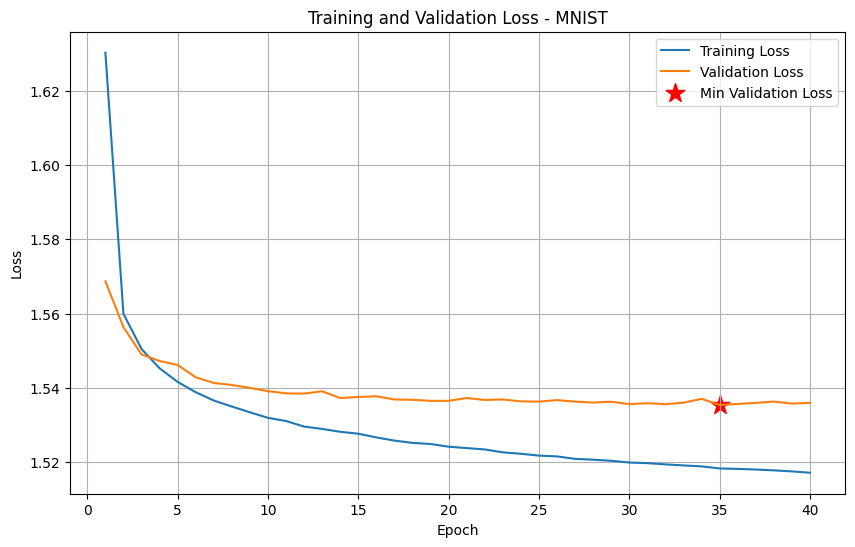

 - Accuracy: 0.9313
 - Precision: 0.9316
 - Recall: 0.9313
 - F1 Score: 0.9312


Training on CIFAR10 dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18278/3749027226.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datas

Epoch [1/40], Loss: 2.1011, Val Loss: 2.0803
Epoch [2/40], Loss: 2.0665, Val Loss: 2.0723
Epoch [3/40], Loss: 2.0546, Val Loss: 2.0808
Epoch [4/40], Loss: 2.0469, Val Loss: 2.0729
Epoch [5/40], Loss: 2.0389, Val Loss: 2.0667
Epoch [6/40], Loss: 2.0363, Val Loss: 2.0654
Epoch [7/40], Loss: 2.0307, Val Loss: 2.0613
Epoch [8/40], Loss: 2.0290, Val Loss: 2.0557
Epoch [9/40], Loss: 2.0236, Val Loss: 2.0650
Epoch [10/40], Loss: 2.0218, Val Loss: 2.0624
Epoch [11/40], Loss: 2.0194, Val Loss: 2.0592
Epoch [12/40], Loss: 2.0157, Val Loss: 2.0632
Epoch [13/40], Loss: 2.0124, Val Loss: 2.0626
Epoch [14/40], Loss: 2.0111, Val Loss: 2.0594
Epoch [15/40], Loss: 2.0082, Val Loss: 2.0544
Epoch [16/40], Loss: 2.0072, Val Loss: 2.0609
Epoch [17/40], Loss: 2.0064, Val Loss: 2.0572
Epoch [18/40], Loss: 2.0031, Val Loss: 2.0537
Epoch [19/40], Loss: 2.0013, Val Loss: 2.0566
Epoch [20/40], Loss: 1.9990, Val Loss: 2.0564
Epoch [21/40], Loss: 2.0003, Val Loss: 2.0568
Epoch [22/40], Loss: 1.9976, Val Loss: 2.05

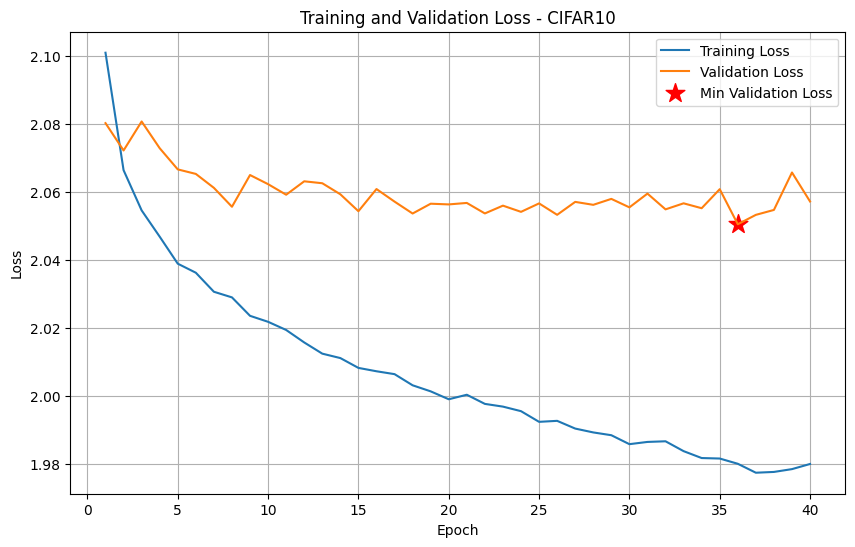

 - Accuracy: 0.4011
 - Precision: 0.3953
 - Recall: 0.4011
 - F1 Score: 0.3949


Training on AIRLINE dataset
Epoch [1/600], Loss: 1.2929, Val Loss: 2.1017
Epoch [2/600], Loss: 1.2107, Val Loss: 1.9818
Epoch [3/600], Loss: 1.1330, Val Loss: 1.8665
Epoch [4/600], Loss: 1.0586, Val Loss: 1.7565
Epoch [5/600], Loss: 0.9860, Val Loss: 1.6510
Epoch [6/600], Loss: 0.9174, Val Loss: 1.5486
Epoch [7/600], Loss: 0.8520, Val Loss: 1.4495
Epoch [8/600], Loss: 0.7916, Val Loss: 1.3556
Epoch [9/600], Loss: 0.7315, Val Loss: 1.2671
Epoch [10/600], Loss: 0.6768, Val Loss: 1.1829
Epoch [11/600], Loss: 0.6259, Val Loss: 1.1035
Epoch [12/600], Loss: 0.5788, Val Loss: 1.0302
Epoch [13/600], Loss: 0.5354, Val Loss: 0.9637
Epoch [14/600], Loss: 0.4947, Val Loss: 0.9024
Epoch [15/600], Loss: 0.4597, Val Loss: 0.8451
Epoch [16/600], Loss: 0.4262, Val Loss: 0.7921
Epoch [17/600], Loss: 0.3964, Val Loss: 0.7427
Epoch [18/600], Loss: 0.3682, Val Loss: 0.6966
Epoch [19/600], Loss: 0.3434, Val Loss: 0.6537
Epoch [

/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18278/3749027226.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datas

Epoch [41/600], Loss: 0.1344, Val Loss: 0.2438
Epoch [42/600], Loss: 0.1321, Val Loss: 0.2376
Epoch [43/600], Loss: 0.1301, Val Loss: 0.2323
Epoch [44/600], Loss: 0.1282, Val Loss: 0.2274
Epoch [45/600], Loss: 0.1266, Val Loss: 0.2229
Epoch [46/600], Loss: 0.1250, Val Loss: 0.2188
Epoch [47/600], Loss: 0.1235, Val Loss: 0.2152
Epoch [48/600], Loss: 0.1220, Val Loss: 0.2118
Epoch [49/600], Loss: 0.1207, Val Loss: 0.2087
Epoch [50/600], Loss: 0.1194, Val Loss: 0.2062
Epoch [51/600], Loss: 0.1181, Val Loss: 0.2042
Epoch [52/600], Loss: 0.1169, Val Loss: 0.2022
Epoch [53/600], Loss: 0.1157, Val Loss: 0.2003
Epoch [54/600], Loss: 0.1144, Val Loss: 0.1987
Epoch [55/600], Loss: 0.1133, Val Loss: 0.1968
Epoch [56/600], Loss: 0.1121, Val Loss: 0.1949
Epoch [57/600], Loss: 0.1109, Val Loss: 0.1934
Epoch [58/600], Loss: 0.1097, Val Loss: 0.1922
Epoch [59/600], Loss: 0.1086, Val Loss: 0.1911
Epoch [60/600], Loss: 0.1074, Val Loss: 0.1901
Epoch [61/600], Loss: 0.1063, Val Loss: 0.1892
Epoch [62/600

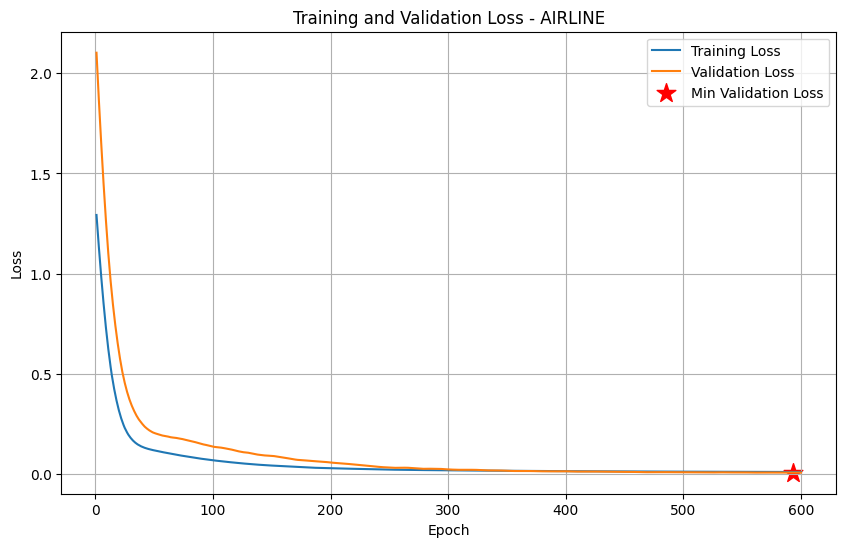

 - Mean Squared Error: 0.0323
 - R² Score: 0.9151


Training on ADULT dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18278/3749027226.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datas

Epoch [1/200], Loss: 0.5593, Val Loss: 0.5015
Epoch [2/200], Loss: 0.4882, Val Loss: 0.4811
Epoch [3/200], Loss: 0.4751, Val Loss: 0.4731
Epoch [4/200], Loss: 0.4689, Val Loss: 0.4685
Epoch [5/200], Loss: 0.4651, Val Loss: 0.4655
Epoch [6/200], Loss: 0.4625, Val Loss: 0.4633
Epoch [7/200], Loss: 0.4606, Val Loss: 0.4618
Epoch [8/200], Loss: 0.4591, Val Loss: 0.4605
Epoch [9/200], Loss: 0.4578, Val Loss: 0.4595
Epoch [10/200], Loss: 0.4568, Val Loss: 0.4588
Epoch [11/200], Loss: 0.4560, Val Loss: 0.4582
Epoch [12/200], Loss: 0.4553, Val Loss: 0.4577
Epoch [13/200], Loss: 0.4547, Val Loss: 0.4573
Epoch [14/200], Loss: 0.4543, Val Loss: 0.4569
Epoch [15/200], Loss: 0.4538, Val Loss: 0.4567
Epoch [16/200], Loss: 0.4535, Val Loss: 0.4565
Epoch [17/200], Loss: 0.4532, Val Loss: 0.4563
Epoch [18/200], Loss: 0.4529, Val Loss: 0.4562
Epoch [19/200], Loss: 0.4527, Val Loss: 0.4562
Epoch [20/200], Loss: 0.4525, Val Loss: 0.4560
Epoch [21/200], Loss: 0.4523, Val Loss: 0.4559
Epoch [22/200], Loss: 

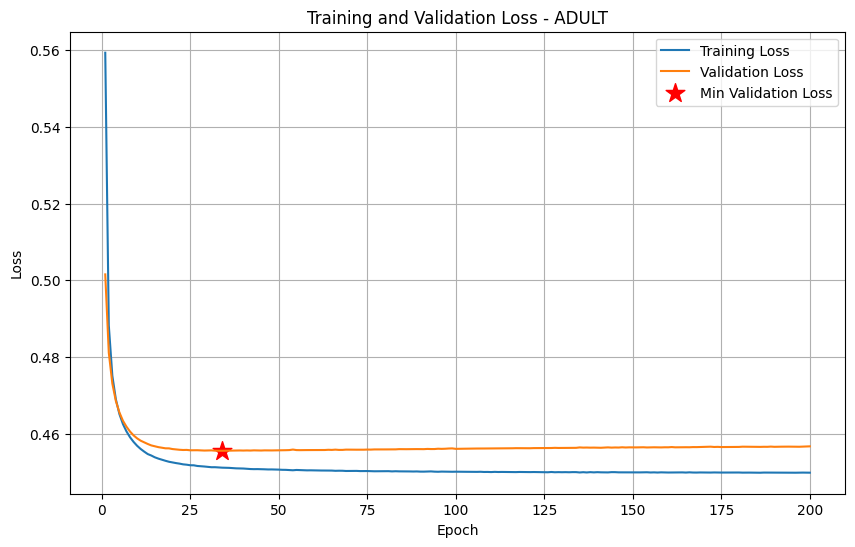

 - Accuracy: 0.8551
 - Precision: 0.8496
 - Recall: 0.8551
 - F1 Score: 0.8508


In [13]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult']
EPOCHS = [40,40,600,200]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = LinearModel(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")


## 2) Multilayer Perceptron (MLP)

MPS is available


Training on MNIST dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18854/255489534.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datase

Epoch [1/40], Loss: 1.5961, Val Loss: 1.5284
Epoch [2/40], Loss: 1.5204, Val Loss: 1.5141
Epoch [3/40], Loss: 1.5078, Val Loss: 1.5038
Epoch [4/40], Loss: 1.4999, Val Loss: 1.5001
Epoch [5/40], Loss: 1.4947, Val Loss: 1.4990
Epoch [6/40], Loss: 1.4923, Val Loss: 1.5001
Epoch [7/40], Loss: 1.4895, Val Loss: 1.4928
Epoch [8/40], Loss: 1.4877, Val Loss: 1.4944
Epoch [9/40], Loss: 1.4872, Val Loss: 1.4922
Epoch [10/40], Loss: 1.4841, Val Loss: 1.4945
Epoch [11/40], Loss: 1.4848, Val Loss: 1.4935
Epoch [12/40], Loss: 1.4821, Val Loss: 1.4933
Epoch [13/40], Loss: 1.4820, Val Loss: 1.4942
Epoch [14/40], Loss: 1.4808, Val Loss: 1.4890
Epoch [15/40], Loss: 1.4808, Val Loss: 1.4922
Epoch [16/40], Loss: 1.4809, Val Loss: 1.4867
Epoch [17/40], Loss: 1.4808, Val Loss: 1.4973
Epoch [18/40], Loss: 1.4784, Val Loss: 1.4904
Epoch [19/40], Loss: 1.4791, Val Loss: 1.4922
Epoch [20/40], Loss: 1.4787, Val Loss: 1.4892
Epoch [21/40], Loss: 1.4786, Val Loss: 1.4904
Epoch [22/40], Loss: 1.4781, Val Loss: 1.48

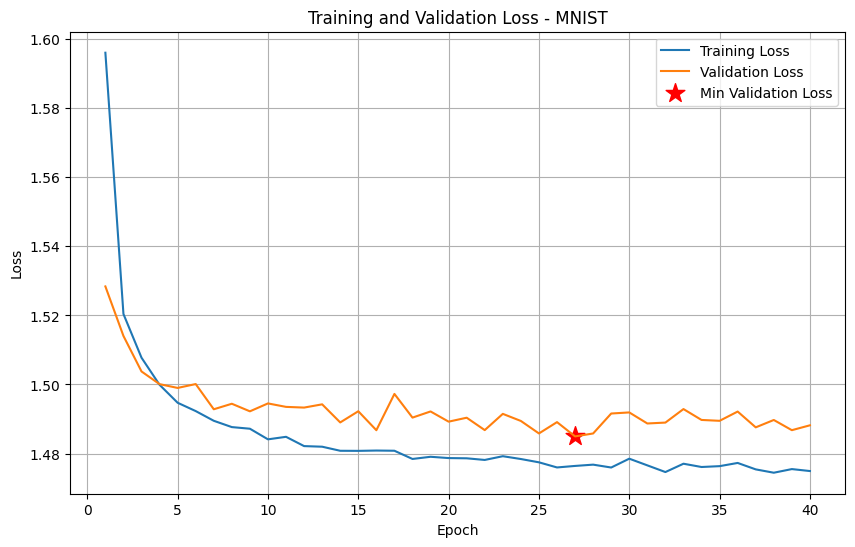

 - Accuracy: 0.9739
 - Precision: 0.9741
 - Recall: 0.9739
 - F1 Score: 0.9739


Training on CIFAR10 dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18854/255489534.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datase

Epoch [1/40], Loss: 2.1056, Val Loss: 2.0873
Epoch [2/40], Loss: 2.0612, Val Loss: 2.0562
Epoch [3/40], Loss: 2.0423, Val Loss: 2.0582
Epoch [4/40], Loss: 2.0282, Val Loss: 2.0317
Epoch [5/40], Loss: 2.0179, Val Loss: 2.0265
Epoch [6/40], Loss: 2.0120, Val Loss: 2.0343
Epoch [7/40], Loss: 2.0111, Val Loss: 2.0315
Epoch [8/40], Loss: 2.0046, Val Loss: 2.0326
Epoch [9/40], Loss: 2.0038, Val Loss: 2.0282
Epoch [10/40], Loss: 1.9941, Val Loss: 2.0266
Epoch [11/40], Loss: 1.9908, Val Loss: 2.0280
Epoch [12/40], Loss: 1.9934, Val Loss: 2.0200
Epoch [13/40], Loss: 1.9942, Val Loss: 2.0291
Epoch [14/40], Loss: 1.9964, Val Loss: 2.0437
Epoch [15/40], Loss: 1.9869, Val Loss: 2.0233
Epoch [16/40], Loss: 1.9902, Val Loss: 2.0310
Epoch [17/40], Loss: 1.9907, Val Loss: 2.0167
Epoch [18/40], Loss: 1.9807, Val Loss: 2.0165
Epoch [19/40], Loss: 1.9840, Val Loss: 2.0021
Epoch [20/40], Loss: 1.9804, Val Loss: 2.0147
Epoch [21/40], Loss: 1.9811, Val Loss: 2.0265
Epoch [22/40], Loss: 1.9875, Val Loss: 2.02

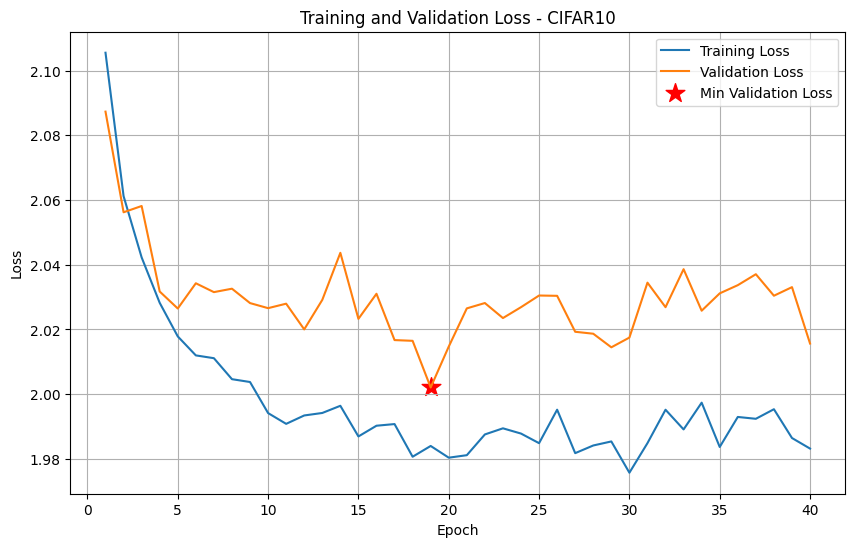

 - Accuracy: 0.4492
 - Precision: 0.4529
 - Recall: 0.4492
 - F1 Score: 0.4455


Training on AIRLINE dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18854/255489534.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datase

Epoch [1/600], Loss: 0.3853, Val Loss: 0.4720
Epoch [2/600], Loss: 0.2706, Val Loss: 0.3573
Epoch [3/600], Loss: 0.1976, Val Loss: 0.2839
Epoch [4/600], Loss: 0.1610, Val Loss: 0.2384
Epoch [5/600], Loss: 0.1492, Val Loss: 0.1990
Epoch [6/600], Loss: 0.1318, Val Loss: 0.1599
Epoch [7/600], Loss: 0.1185, Val Loss: 0.1262
Epoch [8/600], Loss: 0.1010, Val Loss: 0.1039
Epoch [9/600], Loss: 0.0893, Val Loss: 0.0906
Epoch [10/600], Loss: 0.0804, Val Loss: 0.0826
Epoch [11/600], Loss: 0.0721, Val Loss: 0.0724
Epoch [12/600], Loss: 0.0616, Val Loss: 0.0634
Epoch [13/600], Loss: 0.0514, Val Loss: 0.0584
Epoch [14/600], Loss: 0.0449, Val Loss: 0.0551
Epoch [15/600], Loss: 0.0395, Val Loss: 0.0512
Epoch [16/600], Loss: 0.0353, Val Loss: 0.0472
Epoch [17/600], Loss: 0.0321, Val Loss: 0.0417
Epoch [18/600], Loss: 0.0290, Val Loss: 0.0367
Epoch [19/600], Loss: 0.0255, Val Loss: 0.0332
Epoch [20/600], Loss: 0.0232, Val Loss: 0.0305
Epoch [21/600], Loss: 0.0214, Val Loss: 0.0293
Epoch [22/600], Loss: 

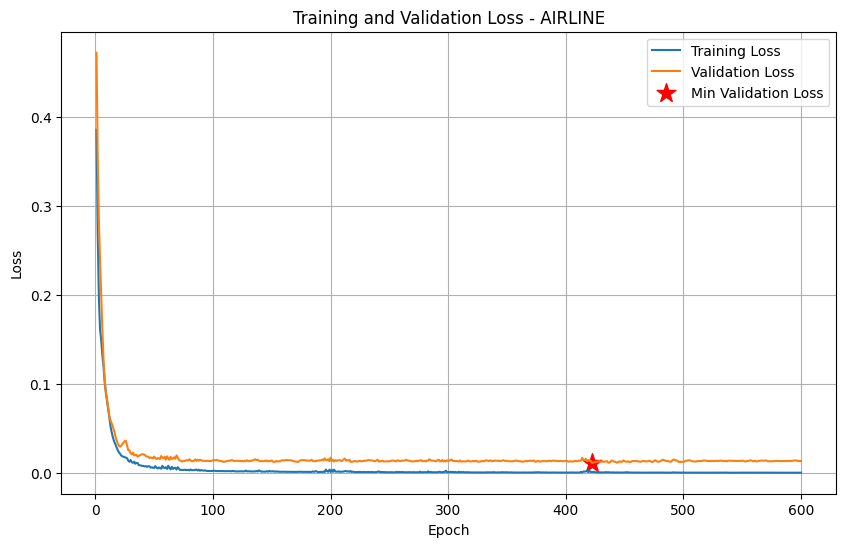

 - Mean Squared Error: 0.0912
 - R² Score: 0.7600


Training on ADULT dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_18854/255489534.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datase

Epoch [1/200], Loss: 0.4719, Val Loss: 0.4493
Epoch [2/200], Loss: 0.4492, Val Loss: 0.4496
Epoch [3/200], Loss: 0.4470, Val Loss: 0.4488
Epoch [4/200], Loss: 0.4448, Val Loss: 0.4499
Epoch [5/200], Loss: 0.4425, Val Loss: 0.4503
Epoch [6/200], Loss: 0.4410, Val Loss: 0.4484
Epoch [7/200], Loss: 0.4395, Val Loss: 0.4497
Epoch [8/200], Loss: 0.4378, Val Loss: 0.4486
Epoch [9/200], Loss: 0.4363, Val Loss: 0.4496
Epoch [10/200], Loss: 0.4346, Val Loss: 0.4522
Epoch [11/200], Loss: 0.4334, Val Loss: 0.4492
Epoch [12/200], Loss: 0.4325, Val Loss: 0.4512
Epoch [13/200], Loss: 0.4309, Val Loss: 0.4518
Epoch [14/200], Loss: 0.4297, Val Loss: 0.4518
Epoch [15/200], Loss: 0.4282, Val Loss: 0.4517
Epoch [16/200], Loss: 0.4264, Val Loss: 0.4520
Epoch [17/200], Loss: 0.4259, Val Loss: 0.4529
Epoch [18/200], Loss: 0.4241, Val Loss: 0.4539
Epoch [19/200], Loss: 0.4234, Val Loss: 0.4549
Epoch [20/200], Loss: 0.4231, Val Loss: 0.4551
Epoch [21/200], Loss: 0.4212, Val Loss: 0.4521
Epoch [22/200], Loss: 

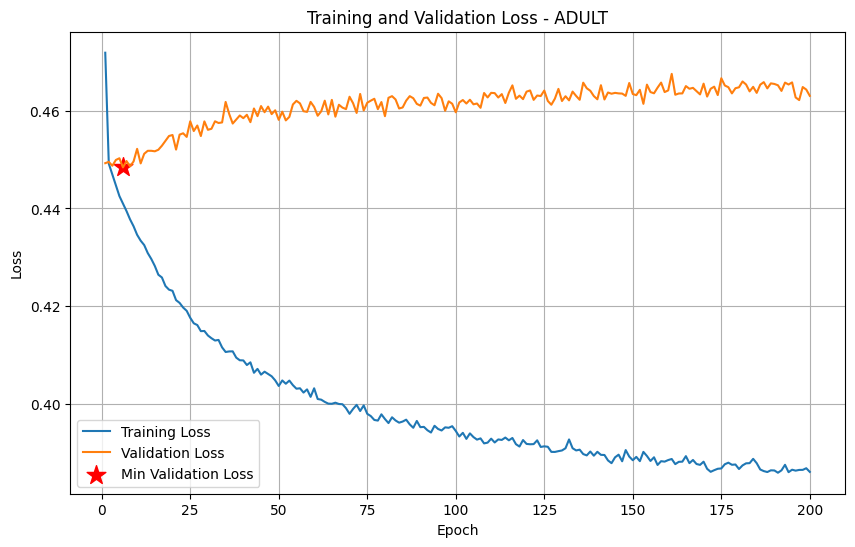

 - Accuracy: 0.8489
 - Precision: 0.8446
 - Recall: 0.8489
 - F1 Score: 0.8462


In [2]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult']
EPOCHS = [40,40,600,200]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = MLP(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

# 3.1) Simple Convolutional Neural Network (CNN)

In [2]:
# Training loop
DATASETS = ['mnist', 'cifar10']
EPOCHS = [150,150]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = CNN(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

MPS is available


Training on MNIST dataset
Epoch [1/150], Loss: 1.9217, Val Loss: 1.7799
Epoch [2/150], Loss: 1.7606, Val Loss: 1.7353
Epoch [3/150], Loss: 1.7337, Val Loss: 1.7187
Epoch [4/150], Loss: 1.7207, Val Loss: 1.7086
Epoch [5/150], Loss: 1.7131, Val Loss: 1.7017
Epoch [6/150], Loss: 1.7075, Val Loss: 1.6977
Epoch [7/150], Loss: 1.7031, Val Loss: 1.6943
Epoch [8/150], Loss: 1.7000, Val Loss: 1.6914
Epoch [9/150], Loss: 1.6972, Val Loss: 1.6888
Epoch [10/150], Loss: 1.6949, Val Loss: 1.6866
Epoch [11/150], Loss: 1.6930, Val Loss: 1.6856
Epoch [12/150], Loss: 1.6913, Val Loss: 1.6841
Epoch [13/150], Loss: 1.6900, Val Loss: 1.6833
Epoch [14/150], Loss: 1.6884, Val Loss: 1.6835
Epoch [15/150], Loss: 1.6873, Val Loss: 1.6807
Epoch [16/150], Loss: 1.6862, Val Loss: 1.6803
Epoch [17/150], Loss: 1.6855, Val Loss: 1.6792
Epoch [18/150], Loss: 1.6846, Val Loss: 1.6787
Epoch [19/150], Loss: 1.6836, Val Loss: 1.6780
Epoch [20/150], Loss: 1.6829, Val Loss: 1.6778
Epoch [21/150], Loss: 1.

## 3.2) Convolutional Neural Network (CNN) - LeNet5

MPS is available


Training on MNIST dataset
Epoch [1/100], Loss: 1.9852, Val Loss: 1.8240
Epoch [2/100], Loss: 1.7922, Val Loss: 1.7724
Epoch [3/100], Loss: 1.7611, Val Loss: 1.7521
Epoch [4/100], Loss: 1.7465, Val Loss: 1.7409
Epoch [5/100], Loss: 1.7369, Val Loss: 1.7333
Epoch [6/100], Loss: 1.7305, Val Loss: 1.7265
Epoch [7/100], Loss: 1.7250, Val Loss: 1.7231
Epoch [8/100], Loss: 1.7208, Val Loss: 1.7190
Epoch [9/100], Loss: 1.7167, Val Loss: 1.7162
Epoch [10/100], Loss: 1.7131, Val Loss: 1.7136
Epoch [11/100], Loss: 1.7100, Val Loss: 1.7093
Epoch [12/100], Loss: 1.7074, Val Loss: 1.7081
Epoch [13/100], Loss: 1.7049, Val Loss: 1.7067
Epoch [14/100], Loss: 1.7031, Val Loss: 1.7042
Epoch [15/100], Loss: 1.7014, Val Loss: 1.7031
Epoch [16/100], Loss: 1.6997, Val Loss: 1.7011
Epoch [17/100], Loss: 1.6984, Val Loss: 1.7010
Epoch [18/100], Loss: 1.6975, Val Loss: 1.6996
Epoch [19/100], Loss: 1.6962, Val Loss: 1.6981
Epoch [20/100], Loss: 1.6950, Val Loss: 1.6971
Epoch [21/100], Loss: 1.

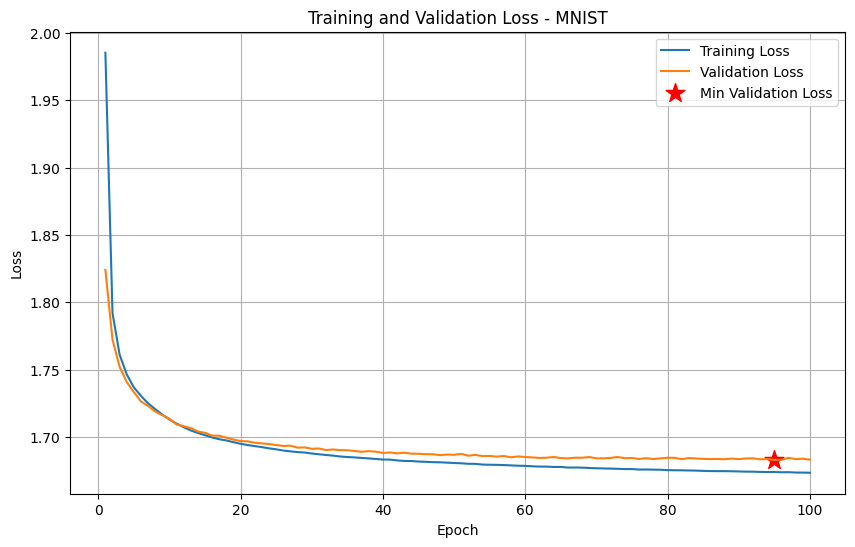

/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 - Accuracy: 0.7769
 - Precision: 0.6295
 - Recall: 0.7769
 - F1 Score: 0.6935


Training on CIFAR10 dataset
Epoch [1/100], Loss: 2.2453, Val Loss: 2.2108
Epoch [2/100], Loss: 2.1928, Val Loss: 2.1872
Epoch [3/100], Loss: 2.1730, Val Loss: 2.1729
Epoch [4/100], Loss: 2.1613, Val Loss: 2.1651
Epoch [5/100], Loss: 2.1539, Val Loss: 2.1603
Epoch [6/100], Loss: 2.1486, Val Loss: 2.1545
Epoch [7/100], Loss: 2.1430, Val Loss: 2.1507
Epoch [8/100], Loss: 2.1388, Val Loss: 2.1455
Epoch [9/100], Loss: 2.1345, Val Loss: 2.1426
Epoch [10/100], Loss: 2.1308, Val Loss: 2.1397
Epoch [11/100], Loss: 2.1268, Val Loss: 2.1359
Epoch [12/100], Loss: 2.1240, Val Loss: 2.1334
Epoch [13/100], Loss: 2.1209, Val Loss: 2.1291
Epoch [14/100], Loss: 2.1185, Val Loss: 2.1272
Epoch [15/100], Loss: 2.1160, Val Loss: 2.1272


KeyboardInterrupt: 

In [ ]:
# Training loop
DATASETS = ['mnist', 'cifar10']
EPOCHS = [200,200]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = LeNet5Flexible(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 3.3) Convolutional Neural Network (CNN) - ResNet 9

MPS is available


Training on MNIST dataset
Epoch [1/10], Loss: 0.1113, Val Loss: 0.0399
Epoch [2/10], Loss: 0.0401, Val Loss: 0.0368
Epoch [3/10], Loss: 0.0268, Val Loss: 0.0419
Epoch [4/10], Loss: 0.0219, Val Loss: 0.0470
Epoch [5/10], Loss: 0.0173, Val Loss: 0.0382
Epoch [6/10], Loss: 0.0156, Val Loss: 0.0593
Epoch [7/10], Loss: 0.0133, Val Loss: 0.0371
Epoch [8/10], Loss: 0.0102, Val Loss: 0.0371
Epoch [9/10], Loss: 0.0122, Val Loss: 0.0506
Epoch [10/10], Loss: 0.0077, Val Loss: 0.0309


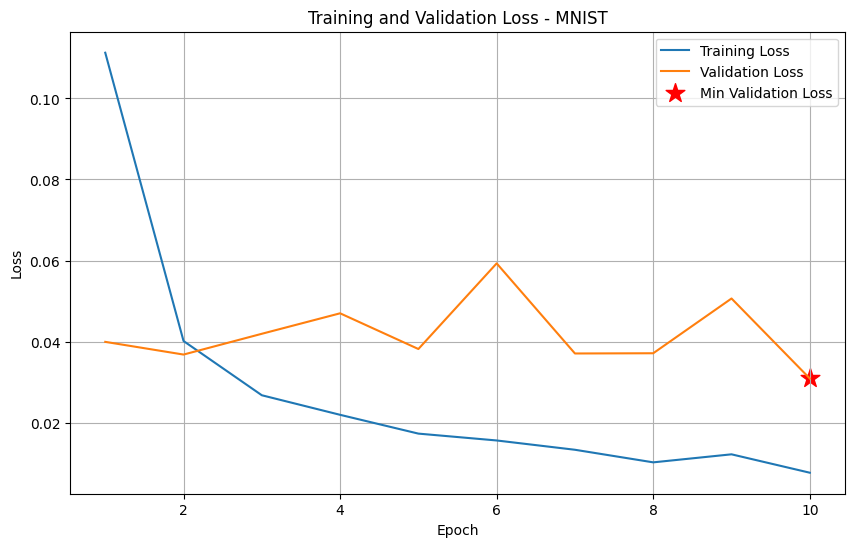

 - Accuracy: 0.9923
 - Precision: 0.9923
 - Recall: 0.9923
 - F1 Score: 0.9923


Training on CIFAR10 dataset
Epoch [1/10], Loss: 1.2969, Val Loss: 1.0154
Epoch [2/10], Loss: 0.8464, Val Loss: 0.8080
Epoch [3/10], Loss: 0.6373, Val Loss: 0.7598
Epoch [4/10], Loss: 0.4824, Val Loss: 0.8340
Epoch [5/10], Loss: 0.3499, Val Loss: 0.6099
Epoch [6/10], Loss: 0.2243, Val Loss: 0.7062
Epoch [7/10], Loss: 0.1503, Val Loss: 0.7269
Epoch [8/10], Loss: 0.1003, Val Loss: 0.8921
Epoch [9/10], Loss: 0.0814, Val Loss: 0.8904
Epoch [10/10], Loss: 0.0712, Val Loss: 1.0073


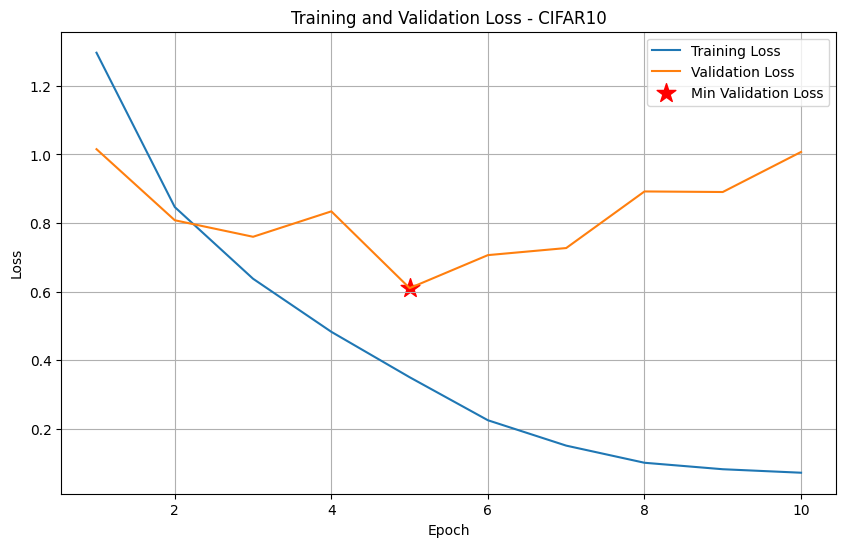

 - Accuracy: 0.7664
 - Precision: 0.7827
 - Recall: 0.7664
 - F1 Score: 0.7639


In [ ]:
# Training loop
DATASETS = ['mnist', 'cifar10']
EPOCHS = [25,25]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = ResNet9(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")